# Reinforcement Learning Individual Assignment
## Text Flappy Bird - GLIE Monte-Carlo Control Agent

In [1]:
import os, sys
import gymnasium as gym
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm import tqdm
import time
import pickle
from pathlib import Path
from joblib import Parallel, delayed

import text_flappy_bird_gym

In [ ]:
TRAIN_AGENT = False
SAVE_AGENT = False

## 1. Environment Setup

We use the simple state variant `TextFlappyBird-v0` which returns `(x_distance, y_distance)` - the horizontal and vertical distance from the bird to the centre of the nearest pipe gap. The action space is `Discrete(2)`: **0 = idle** (do nothing), **1 = flap**.

In [3]:
# Initialise the environment (simple state: x_dist, y_dist)
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)

obs, info = env.reset()
print(f"Observation: {obs}")
print(f"Action space: {env.action_space}")  # Discrete(2)

Observation: (13, -5)
Action space: Discrete(2)


## 2. GLIE Monte-Carlo Control Agent

The agent maintains:
- **Q(s, a)**: action-value estimates (dictionary keyed by `(state, action)`)
- **N(s, a)**: visit counts for each state-action pair
- **$\epsilon$**: exploration rate, decayed as $\epsilon = 1/k$ (episode number) to satisfy the GLIE condition

The $\epsilon$-greedy policy selects:
- the greedy action with probability $1 - \epsilon + \epsilon/m$
- each non-greedy action with probability $\epsilon/m$

where $m$ is the number of actions.

In [4]:
class GLIEMCAgent:
    """GLIE Monte-Carlo Control agent for Text Flappy Bird."""

    def __init__(self, n_actions: int = 2, min_epsilon: float = 0.01, max_epsilon: float = 1.0, decay_step: float = 0.0001, lambda_: float = 0.0001):
        self.n_actions = n_actions
        self.min_epsilon = min_epsilon
        self.max_epsilon = max_epsilon
        self.decay_step = decay_step    # for linear decay
        self.lambda_ = lambda_          # for exponential decay
        # Q-values and visit counts stored as dicts for sparse state space
        self.Q = defaultdict(float)         # (state, action) -> value
        self.N = defaultdict(int)           # (state, action) -> visit count
        self.epsilon = 1.0
        self.episode_count = 0

    # policy
    def get_action(self, state: tuple) -> int:
        """Select an action using the epsilon-greedy policy w.r.t. current Q."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        # greedy: pick action with highest Q (break ties randomly)
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best_actions)

    def greedy_action(self, state: tuple) -> int:
        """Purely greedy action (for evaluation)."""
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best_actions)

    # learning
    def update(self, episode: list[tuple], gamma: float = 1.0):
        """
        Update Q from a complete episode using first-visit MC.

        Parameters
        ----------
        episode : list of (state, action, reward) tuples
        gamma   : discount factor (1.0 for undiscounted)
        """
        G = 0.0
        visited = set()
        # Walk backwards through the episode
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward

            sa = (state, action)
            # First-visit: only update the first time we see (s, a)
            if sa not in visited:
                visited.add(sa)
                self.N[sa] += 1
                # Incremental mean update: Q ← Q + (1/N)(G - Q)
                self.Q[sa] += (1.0 / self.N[sa]) * (G - self.Q[sa])

    def decay_epsilon(self, n_episodes: int, decay_type: str = "linear"):
        """GLIE epsilon decay: linear decay over all training episodes."""
        self.episode_count += 1
        if decay_type == "inverse":
            self.epsilon = max(self.min_epsilon, 1.0 / self.episode_count)
        elif decay_type == "linear":
            self.epsilon = max(self.min_epsilon, self.max_epsilon - self.episode_count * self.decay_step)
        elif decay_type == "exponential":
            self.epsilon = self.min_epsilon + (self.max_epsilon - self.min_epsilon) * np.exp(- self.lambda_ * self.episode_count)

## 3. Training Loop

We run thousands of episodes. In each episode we:
1. Generate a full trajectory under the current $\epsilon$-greedy policy.
2. Compute returns and update $Q(s,a)$ (first-visit MC).
3. Decay $\epsilon$.

In [5]:
def train(env, agent, n_episodes: int = 50_000, gamma: float = 1.0, log_every: int = 1000, decay_type: str = "linear"):
    """Train the GLIE MC agent and return training statistics."""
    reward_history = []     # total reward per episode
    avg_rewards = []        # running average (over last `log_every` episodes)
    epsilon_history = []
    print(f"Starting training with {n_episodes} episodes, gamma={gamma}, decay_type={decay_type}")
    for k in tqdm(range(1, n_episodes + 1), desc="Training"):
        # Generate an episode
        obs, _ = env.reset()
        state = tuple(obs)
        episode = []
        total_reward = 0.0

        done = False
        while not done:
            action = agent.get_action(state)
            next_obs, reward, done, _, info = env.step(action)
            episode.append((state, action, reward))
            total_reward += reward
            state = tuple(next_obs)

        # Update Q-values
        agent.update(episode, gamma=gamma)

        # Decay epsilon (GLIE)
        agent.decay_epsilon(n_episodes, decay_type=decay_type)

        # Logging
        reward_history.append(total_reward)
        epsilon_history.append(agent.epsilon)

        if k % log_every == 0:
            avg_r = np.mean(reward_history[-log_every:])
            avg_rewards.append(avg_r)
            print(f"Episode {k:>7d} | Avg reward (last {log_every}): {avg_r:7.2f} "
                  f"| \u03B5: {agent.epsilon:.5f} | Q-table size: {len(agent.Q)}")

    return reward_history, avg_rewards, epsilon_history

In [6]:
# Hyperparameters
N_EPISODES = 50_000
GAMMA = 0.99
MIN_EPSILON = 0.05
MAX_EPSILON = 1.0
DECAY_STEP = 0.005     # for linear decay
LAMBDA = 0.001         # for exponential decay
DECAY_TYPE = "linear"  # "linear", "inverse", or "exponential"

# Create agent
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
agent = GLIEMCAgent(n_actions=env.action_space.n, min_epsilon=MIN_EPSILON, max_epsilon=MAX_EPSILON, decay_step=DECAY_STEP, lambda_=LAMBDA)

In [7]:
results_dir = Path.cwd().parent / 'results' / 'MC'
results_dir.mkdir(parents=True, exist_ok=True)
save_path = results_dir / 'mc_agent.pkl'

# Train or load agent
if TRAIN_AGENT:
    reward_history, avg_rewards, epsilon_history = train(env, agent, n_episodes=N_EPISODES, gamma=GAMMA, decay_type=DECAY_TYPE)

    # Save the trained Q-table
    if SAVE_AGENT:
        with open(save_path, 'wb') as f:
            pickle.dump({'Q': dict(agent.Q), 'N': dict(agent.N),
                         'epsilon': agent.epsilon, 'episode_count': agent.episode_count}, f)
        print(f"Agent saved to {save_path}")
else:
    if save_path.exists():
        with open(save_path, 'rb') as f:
            data = pickle.load(f)
        agent.Q = defaultdict(float, data['Q'])
        agent.N = defaultdict(int, data['N'])
        agent.epsilon = data['epsilon']
        agent.episode_count = data['episode_count']
        print(f"Agent loaded from {save_path}")
    else:
        print(f"No saved agent found at {save_path}. Please train the agent first.")

Starting training with 50000 episodes, gamma=0.99, decay_type=linear


Training:   2%|▏         | 1046/50000 [00:02<02:48, 291.28it/s]

Episode    1000 | Avg reward (last 1000):   72.65 | ε: 0.05000 | Q-table size: 525


Training:   4%|▍         | 2044/50000 [00:06<02:23, 334.97it/s]

Episode    2000 | Avg reward (last 1000):   96.66 | ε: 0.05000 | Q-table size: 528


...

Episode   48000 | Avg reward (last 1000):  139.57 | ε: 0.05000 | Q-table size: 540


Training:  98%|█████████▊| 49045/50000 [03:21<00:04, 225.98it/s]

Episode   49000 | Avg reward (last 1000):  134.69 | ε: 0.05000 | Q-table size: 540


Training: 100%|██████████| 50000/50000 [03:25<00:00, 243.35it/s]

Episode   50000 | Avg reward (last 1000):  138.84 | ε: 0.05000 | Q-table size: 540
Agent saved to c:\Users\adoni\Desktop\Reinforcement Learning\MDS-RL\individual assignment\results\MC\mc_agent.pkl


## 4. Training Curves

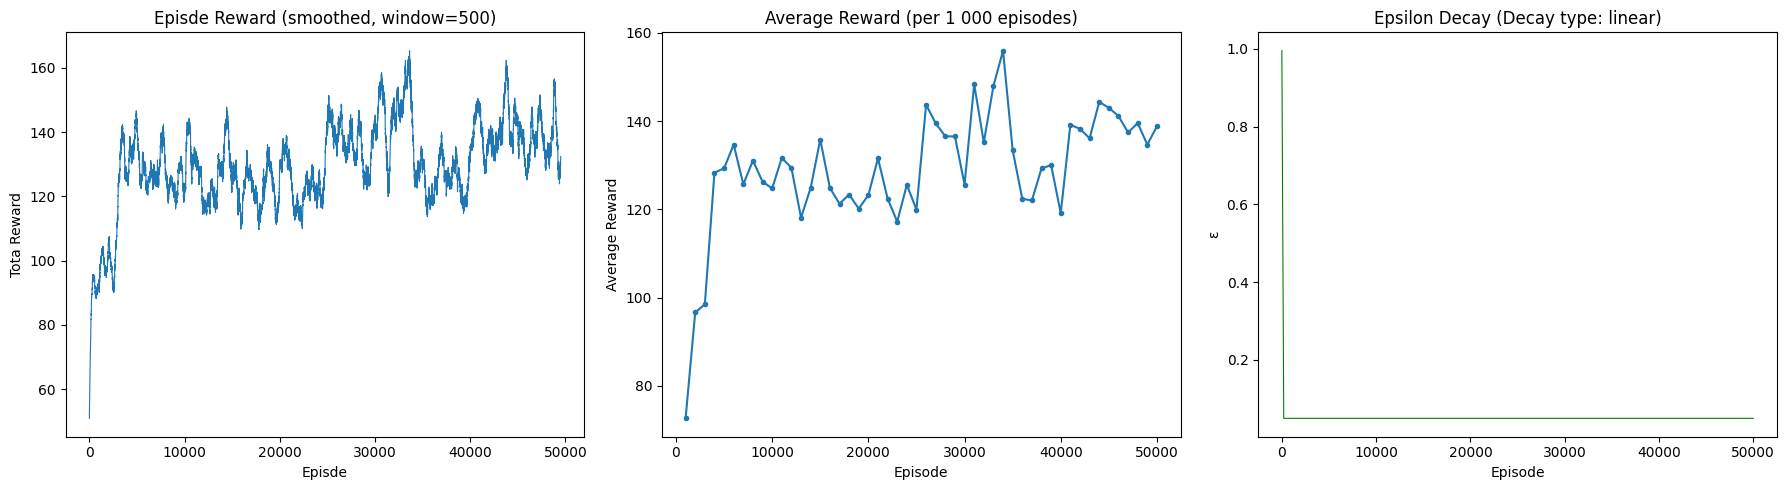

In [8]:
if TRAIN_AGENT:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Episode reward (smoothed)
    window = 500

    smoothed = np.convolve(reward_history, np.ones(window)/window, mode='valid')
    axes[0].plot(smoothed, linewidth=0.8)
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Total Reward')
    axes[0].set_title(f'Episode Reward (smoothed, window={window})')

    # Average reward per loging interval
    axes[1].plot(range(1000, N_EPISODES + 1, 1000), avg_rewards, marker='o', markersize=3)
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Average Reward')
    axes[1].set_title('Average Reward (per 1 000 episodes)')

    # Epsilon decay
    axes[2].plot(epsilon_history, linewidth=0.8, color='green')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('\u03B5')
    axes[2].set_title(f'Epsilon Decay (Decay type: {DECAY_TYPE})')

    plt.tight_layout()
    plt.savefig(results_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Evaluation (Greedy Policy)

Run the fully trained agent (greedy, $\epsilon = 0$) for several episodes to measure its average performance.

Evaluating: 100%|██████████| 1000/1000 [00:59<00:00, 16.78it/s]


Greedy evaluation over 1 000 episodes:
    Mean reward: 2236.89
    Std reward : 1656.66
    Max reward : 5000
    Min reward : 36


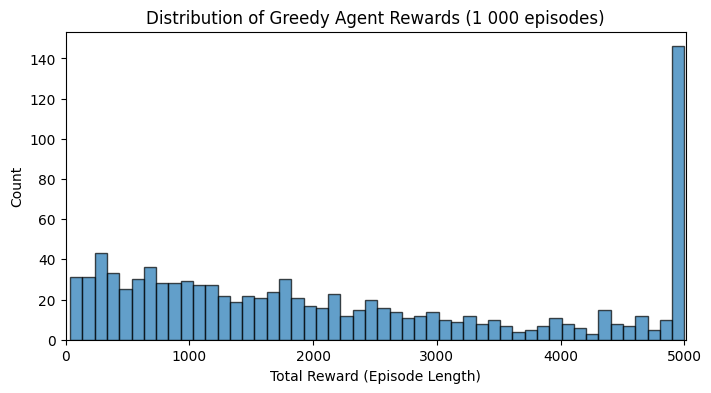

In [9]:
def evaluate(env, agent, n_episodes: int = 1000, max_steps: int = 5000):
    """Evaluate the agent using a purely greedy policy (no exploration)."""
    total_rewards = []
    for _ in tqdm(range(n_episodes), desc="Evaluating"):
        obs, _ = env.reset()
        state = tuple(obs)
        total_reward = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = agent.greedy_action(state)
            obs, reward, done, _, info = env.step(action)
            state = tuple(obs)
            total_reward += reward
            steps += 1
        total_rewards.append(total_reward)
    return total_rewards

eval_rewards = evaluate(env, agent, n_episodes=1000)
print(f"Greedy evaluation over 1 000 episodes:")
print(f"    Mean reward: {np.mean(eval_rewards):.2f}")
print(f"    Std reward : {np.std(eval_rewards):.2f}")
print(f"    Max reward : {np.max(eval_rewards):.0f}")
print(f"    Min reward : {np.min(eval_rewards):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(eval_rewards, bins=50, edgecolor='black', alpha=0.7)
plt.xlim(0, max(eval_rewards) + 10)
plt.xlabel('Total Reward (Episode Length)')
plt.ylabel('Count')
plt.title('Distribution of Greedy Agent Rewards (1 000 episodes)')
plt.savefig(results_dir / 'evaluation_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hyperparameter Grid Search

We perform a grid search over decay types and their associated parameters to find the configuration that maximises mean greedy reward after a fixed training budget.

Each configuration is trained for $10,000$ episodes (a reduced budget for tractability) and evaluated greedily over $500$ episodes. Configurations are trained in parallel using joblib to speed up the search.

| Decay type | Parameter swept |
|---|---|
| `inverse`     | - |
| `linear`      | `decay_step` |
| `exponential` | `lambda_` |

`min_epsilon` is also swept across all types.

In [10]:
# Grid definition
GS_EPISODES   = 10_000 # training budget per config
GS_EVAL_EPS   = 500   # greedy evaluation episodes per run
GS_GAMMA      = 0.99

min_epsilons   = [0.01, 0.05]
decay_steps    = [0.001, 0.005]  # linear
lambdas        = [0.0005, 0.001] # exponential

# Build list of (label, decay_type, agent_kwargs)
grid = []

for me in min_epsilons:
    grid.append((f"inverse | min_\u03B5={me}", "inverse",
                 dict(min_epsilon=me)))

for me in min_epsilons:
    for ds in decay_steps:
        grid.append((f"linear | step={ds} | min_\u03B5={me}", "linear",
                     dict(min_epsilon=me, decay_step=ds)))

for me in min_epsilons:
    for lm in lambdas:
        grid.append((f"exponential | \u03BB={lm} | min_\u03B5={me}", "exponential",
                     dict(min_epsilon=me, lambda_=lm)))

print(f"Total configurations: {len(grid)}")
print(f"Total training episodes: {len(grid) * GS_EPISODES:,}")

Total configurations: 10
Total training episodes: 100,000


In [11]:
def _train_and_eval(label, decay_type, kwargs):
    """Train one config and return its evaluation result."""
    import text_flappy_bird_gym  # must register env in worker process
    gs_env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
    gs_agent = GLIEMCAgent(n_actions=gs_env.action_space.n, **kwargs)

    for _ in range(1, GS_EPISODES + 1):
        obs, _ = gs_env.reset()
        state = tuple(obs)
        episode = []
        done = False
        while not done:
            action = gs_agent.get_action(state)
            next_obs, reward, done, _, _ = gs_env.step(action)
            episode.append((state, action, reward))
            state = tuple(next_obs)
        gs_agent.update(episode, gamma=GS_GAMMA)
        gs_agent.decay_epsilon(GS_EPISODES, decay_type=decay_type)

    # Evaluate
    rewards = evaluate(gs_env, gs_agent, n_episodes=GS_EVAL_EPS)
    return {"label": label, "decay_type": decay_type, "kwargs": kwargs,
            "mean_reward": np.mean(rewards), "std_reward": np.std(rewards)}

# Run all configs in parallel
gs_results = Parallel(n_jobs=-1, verbose=10)(
    delayed(_train_and_eval)(label, decay_type, kwargs)
    for label, decay_type, kwargs in grid
)

gs_results.sort(key=lambda r: r["mean_reward"], reverse=True)
print("\nTop 10 configurations:")
print(f"{'Rank':<5} {'Mean Reward':>12} {'Std':>8}  Label")
print("-" * 75)
for i, r in enumerate(gs_results[:10], 1):
    print(f"{i:<5} {r['mean_reward']:>12.2f} {r['std_reward']:>8.2f}  {r['label']}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:  1.0min remaining:  2.4min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:  1.4min remaining:  1.4min
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:  2.4min remaining:  1.0min



Top 10 configurations:
Rank   Mean Reward      Std  Label
---------------------------------------------------------------------------
1          5000.00     0.00  inverse | min_ε=0.01
2          5000.00     0.00  linear | step=0.005 | min_ε=0.01
3          5000.00     0.00  linear | step=0.005 | min_ε=0.05
4          4563.73  1160.30  linear | step=0.001 | min_ε=0.01
5          1554.16  1369.60  linear | step=0.001 | min_ε=0.05
6          1350.33  1222.28  exponential | λ=0.001 | min_ε=0.05
7          1272.13  1233.24  exponential | λ=0.001 | min_ε=0.01
8           849.39   803.93  exponential | λ=0.0005 | min_ε=0.01
9           673.04   664.34  exponential | λ=0.0005 | min_ε=0.05
10          172.84   176.46  inverse | min_ε=0.05


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  4.1min finished


C:\Users\adoni\AppData\Local\Temp\ipykernel_26440\1725655283.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(decay_groups.values(), labels=decay_groups.keys(), patch_artist=True, boxprops=dict(facecolor="lightblue"), medianprops=dict(color="red", linewidth=2))


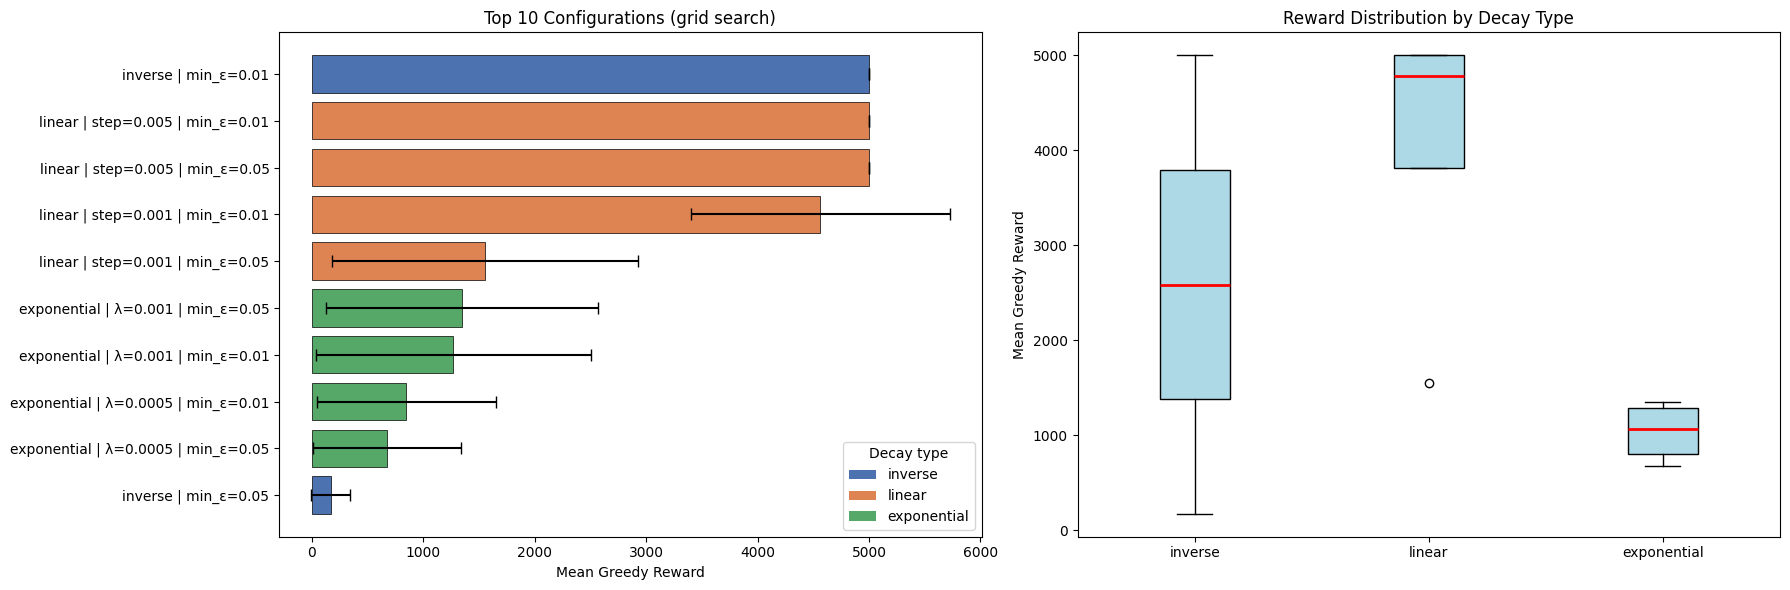


Best configuration found:
    Decay type : inverse
    Parameters : {'min_epsilon': 0.01}
    Mean reward: 5000.00 ± 0.00


In [12]:
# Visualise results
df = pd.DataFrame(gs_results)

# Top 15 configs
top_n = min(15, len(df))
df_top = df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = {"inverse": "#4C72B0", "linear": "#DD8452", "exponential": "#55A868"}
bar_colors = [colors[dt] for dt in df_top["decay_type"]]

axes[0].barh(df_top["label"][::-1], df_top["mean_reward"][::-1], xerr=df_top["std_reward"][::-1], color=bar_colors[::-1], capsize=4, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Mean Greedy Reward")
axes[0].set_title(f"Top {top_n} Configurations (grid search)")
legend_elements = [Patch(facecolor=c, label=l) for l, c in colors.items()]
axes[0].legend(handles=legend_elements, title="Decay type", loc="lower right")

# Mean reward by decay type
decay_groups = {dt: df[df["decay_type"] == dt]["mean_reward"].values for dt in ["inverse", "linear", "exponential"]}
axes[1].boxplot(decay_groups.values(), labels=decay_groups.keys(), patch_artist=True, boxprops=dict(facecolor="lightblue"), medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Mean Greedy Reward")
axes[1].set_title("Reward Distribution by Decay Type")

plt.tight_layout()
plt.savefig(Path.cwd().parent / "results" / "MC" / "gridsearch_results.png", dpi=150, bbox_inches="tight")
plt.show()

best = gs_results[0]
print("\nBest configuration found:")
print(f"    Decay type : {best['decay_type']}")
print(f"    Parameters : {best['kwargs']}")
print(f"    Mean reward: {best['mean_reward']:.2f} ± {best['std_reward']:.2f}")

## 7. Live Demo

Run the trained agent with the screen variant and watch it play in real-time using the scripts/MCAgent.py script.